<div align="center">
  <img src="https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/img/wsu_logo_horizontal.png" alt="Wayne State University Logo" width="320">
  <h1>Practice 5: Classification and Model Performance Evaluation</h1>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week05/practice05_classification_experiments_solution.ipynb)

[Course Repository](https://github.com/WSU-AI-in-ME/ai-in-me-1) · [Practice Index](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/Practice_index.ipynb)

### ME 5995 — AI in Mechanical Engineering I: Fundamentals of Manufacturing Data Science
**Wayne State University · Optional, ungraded self-study · No submission**

**Version: Self-check solution**

Try selected exercises before consulting the [paired notebook](practice05_classification_experiments.ipynb).
Open in Colab and save a personal copy before editing.

## Student Information

Optional for your personal copy. Double-click to edit.

**Student name:** Instructor Example  
**WSU AccessID:** example00

## Overview

Explore classification errors, kNN and Gaussian Naive Bayes by changing one setting
at a time. This is an optional exercise bank, not an assignment to finish in full.
Prerequisites: Lab 5's fit/predict, training/validation and confusion matrices.

**Recommended route: A1 → A2 → B1 → B3 → C2 → D2.** Before C2, run C's one-feature
warm-up. The other ten exercises are extensions; no derivations are required.

| Module | Focus |
|---|---|
| [A — Metrics](#module-a) | A1–A4: counts, imbalance, thresholds, macro-F1 |
| [B — kNN](#module-b) | B1–B4: neighbors, voting, scaling, label noise |
| [C — GaussianNB](#module-c) | Warm-up → C2 priors; C3 duplication; C1 smoothing |
| [D — PHM](#module-d) | D1–D3: binary kNN, multiclass comparison, threshold |
| [E — Optional LDA/QDA](#module-e) | E1–E2: boundaries and training sample size |

### How to use each exercise

1. Run its module setup. Each module is independent; earlier exercise answers are not needed.
2. Read the question and predict a change. Run the completed example, edit the YOUR TURN cell,
   then run its comparison and plot cells. Reporting code is supplied; do not reconstruct it.
3. Copy results into the record table before trying another setting, then answer the specific
   question in short phrases. Tables are edited manually; unchanged results are valid findings.
4. When changing a setting, rerun its action and reporting/plot cells. When switching modules,
   rerun the new setup because variable names are reused. Consult the paired solution after trying.

An unchanged starter is runnable but has not performed the requested experiment.
Record results once in the table; your response can refer to them instead of repeating numbers.

### Setup

Colab: run the imports. Locally: install NumPy, pandas, Matplotlib, scikit-learn and
Jupyter in your Python environment. A/B/C/E use synthetic data. D loads the course
PHM CSV online, or uses a copy placed beside the notebook. No raw signals are needed.
Held-out rows are validation, not final test data; repeated comparisons can overfit them.

Planning estimates: 20–30 minutes per module; 120–150 for the full bank. Actual times
are unmeasured. There is no submission and no need to complete the full bank.

<a id="module-a"></a>

## A — Read errors before trusting a score

All labels in this module are illustrative. Class 1 is the positive class.
Precision = TP/(TP+FP); recall = TP/(TP+FN); F1 = 2TP/(2TP+FP+FN).
The confusion matrix uses actual rows and predicted columns. Run A setup first.

These arrays are invented predictions for learning how metrics work. Changing an entry here is not training a classifier. Never repair real validation predictions by copying their known correct labels.

In [1]:
# PROVIDED SETUP — imports make tools available; they do not train a model.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

### A1 — Recommended: Find the missed positive

Change the final prediction from 0 to 1. Which matrix entry moves?

In [2]:
# COMPLETED EXAMPLE — run unchanged.
actual = np.array([0, 0, 0, 1, 1, 1])
reference_pred = np.array([0, 0, 1, 1, 1, 0])

In [3]:
# YOUR TURN — edit the marked setting/expression.
changed_pred = np.array([0, 0, 1, 1, 1, 1])  # Change an FN into a TP.

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.667,0.667,0.667,0.667,1,1
1,Your variant,0.833,0.750,1.000,0.857,1,0


Predictions that changed: 1


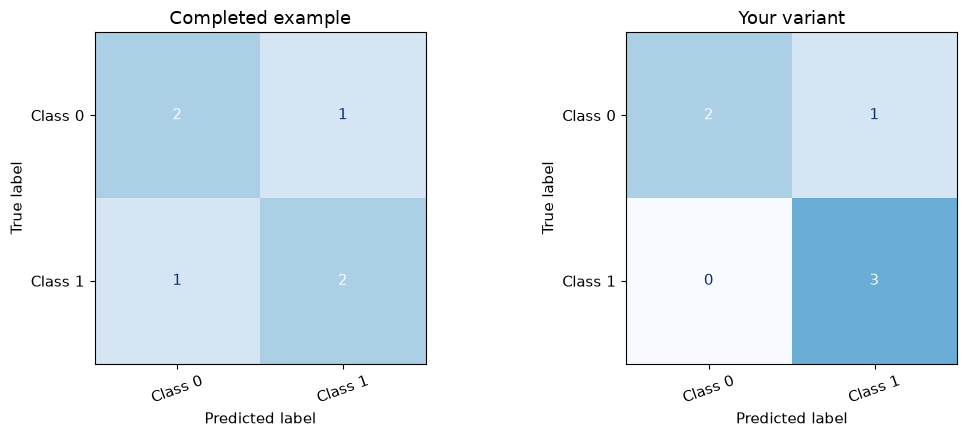

In [4]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

**Question:** Which count changes from FN to TP? Calculate recall before and after. Why is editing this illustrative prediction not a way to improve a trained model?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.667 → 0.857** (reference → variant). FN decreases from 1 to 0 while FP stays 1. Recall rises from 2/3 to 1; precision rises from 2/3 to 3/4. This is a label-reading exercise, not evidence that a trained model can repair this error.

### A2 — Recommended: High accuracy, no detection

The sample has 18 negatives and 2 positives. Try detecting one positive while adding one false alarm. Compare accuracy and F1.

In [5]:
# COMPLETED EXAMPLE — run unchanged.
actual = np.array([0] * 18 + [1, 1])
reference_pred = np.zeros(20, dtype=int)  # Always predict class 0.

In [6]:
# YOUR TURN — edit the marked setting/expression.
changed_pred = reference_pred.copy()
changed_pred[0] = 1  # False alarm.
changed_pred[18] = 1  # Detect one actual positive.

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.9,0.0,0.0,0.0,0,2
1,Your variant,0.9,0.5,0.5,0.5,1,1


Predictions that changed: 2


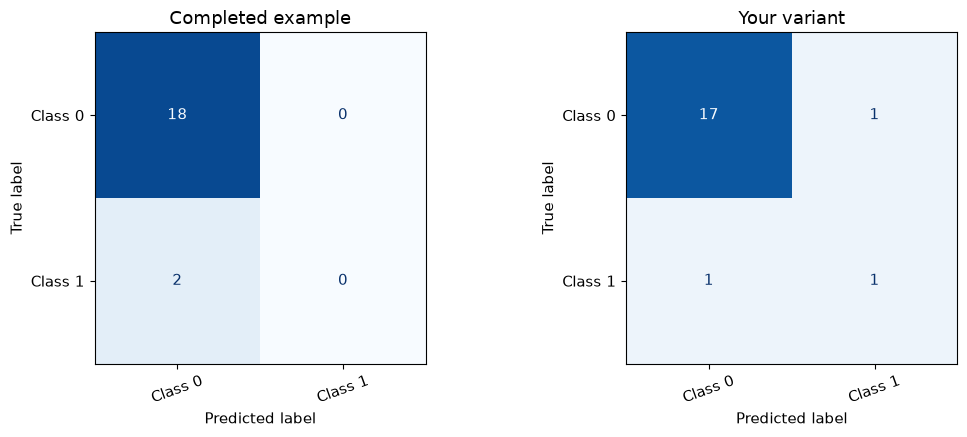

In [7]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

**Question:** Record both accuracies and positive F1 scores. Which prediction set detects any positives, and why does accuracy fail to distinguish the cases?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.000 → 0.500** (reference → variant). Both accuracies are 0.900, but positive F1 changes from 0 to 0.500. Accuracy alone hides whether any rare positive cases are detected. The false-alarm cost is not encoded by F1.

### A3 — Additional: The threshold trade-off

Keep these illustrative probabilities fixed. Lower the decision threshold from 0.50 to 0.30, then inspect FP/FN.

In [8]:
# COMPLETED EXAMPLE — run unchanged.
actual = np.array([0, 0, 0, 0, 1, 1, 1, 1])
probability = np.array([0.10, 0.20, 0.35, 0.60, 0.25, 0.45, 0.70, 0.90])
# The comparison is True where the estimated positive-class probability reaches the cutoff.
reference_pred = (probability >= 0.50).astype(int)

In [9]:
# YOUR TURN — edit the marked setting/expression.
threshold = 0.30
# The comparison is True where the estimated positive-class probability reaches the cutoff.
is_positive = probability >= threshold
# Convert each Boolean decision into a class label: True becomes 1, False becomes 0.
changed_pred = is_positive.astype(int)

In [10]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.625,0.667,0.50,0.571,1,2
1,Your variant,0.625,0.600,0.75,0.667,2,1


Predictions that changed: 2


**Question:** Record FP and FN at each threshold. Which probability values change their predicted class, and how do those cases explain the trade-off?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.571 → 0.667** (reference → variant). FP rises from 1 to 2 and FN falls from 2 to 1. Recall improves, but precision does not necessarily improve. These invented probabilities are not calibrated industrial risks.

### A4 — Additional: Macro-F1 notices the rare classes

Predict one class-1 and one class-2 example correctly instead of always predicting class 0. Compare macro and weighted F1.

Support is the number of actual examples in a class. Macro-F1 averages the class F1 scores equally; weighted-F1 weights them by support.

In [11]:
# COMPLETED EXAMPLE — run unchanged.
actual = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2])
reference_pred = np.zeros(12, dtype=int)

In [12]:
# YOUR TURN — edit the marked setting/expression.
changed_pred = reference_pred.copy()
changed_pred[8] = 1
changed_pred[10] = 2

,Case,Macro-F1,Weighted-F1
0,Completed example,0.267,0.533
1,Your variant,0.741,0.815


              precision    recall  f1-score   support

           0      0.800     1.000     0.889         8
           1      1.000     0.500     0.667         2
           2      1.000     0.500     0.667         2

    accuracy                          0.833        12
   macro avg      0.933     0.667     0.741        12
weighted avg      0.867     0.833     0.815        12



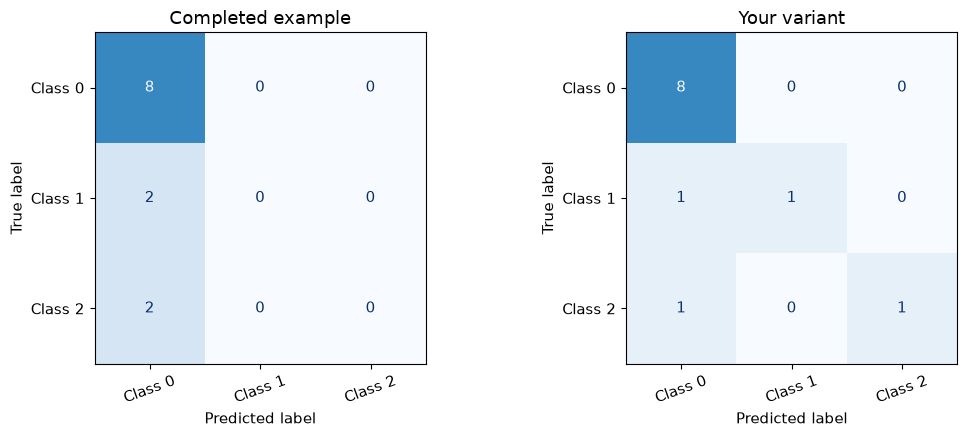

In [13]:
# PROVIDED REPORTING — optional reading; run unchanged.
# macro-F1 weights each class equally; weighted-F1 uses support.
reference_f1 = f1_score(actual, reference_pred, labels=[0, 1, 2], average='macro', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, labels=[0, 1, 2], average='macro', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_weighted = f1_score(actual, reference_pred, labels=[0, 1, 2], average='weighted', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_weighted = f1_score(actual, changed_pred, labels=[0, 1, 2], average='weighted', zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Macro-F1'] = [reference_f1, changed_f1]
comparison['Weighted-F1'] = [reference_weighted, changed_weighted]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
labels = [0, 1, 2]
names = ['Class 0', 'Class 1', 'Class 2']
print(classification_report(actual, changed_pred, labels=labels, digits=3, zero_division=0))
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

**Question:** Record macro-F1 and weighted-F1 before and after. Which class has the largest support, and why do the two averages differ?

**One possible interpretation:** In this fixed run, macro-F1 is **0.267 → 0.741** (reference → variant). Macro-F1 weights all three classes equally; weighted-F1 gives class 0 eight of the twelve support units. Both rise here, but the weighted score initially conceals more rare-class failure.

<a id="module-b"></a>

## B — k-nearest neighbors (kNN)

kNN stores training examples and classifies a new point using nearby examples.
Small k follows local detail; larger k averages over a wider neighborhood.
Distance depends on feature units. Uniform voting gives each neighbor one vote;
distance voting gives closer neighbors more influence. These are synthetic data.

In [14]:
# PROVIDED SETUP — imports make tools available; they do not train a model.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Synthetic features have no physical units and are not measured sensor data.
# Generate once with a fixed seed, then keep the same validation rows for comparisons.
X, y = make_moons(n_samples=240, noise=0.25, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
# Fit scaling only on training rows; use those same statistics for validation.
scaler = StandardScaler()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
scaler.fit(X_train)
# Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
X_train_scaled = scaler.transform(X_train)
# Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
X_valid_scaled = scaler.transform(X_valid)
print('Training / validation rows:', len(y_train), len(y_valid))

Training / validation rows: 180 60


### B1 — Recommended: Change neighborhood size

Compare k=5 with k=1; then try k=15. Keep rows and scaling fixed. Does a larger neighborhood always improve F1?

In [15]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = KNeighborsClassifier(n_neighbors=5, weights='uniform')
reference_model.fit(X_train_scaled, y_train)  # Store training inputs and labels.
reference_pred = reference_model.predict(X_valid_scaled)  # Predict validation labels.

In [16]:
# YOUR TURN — edit the marked setting/expression.
k = 15
changed_model = KNeighborsClassifier(n_neighbors=k)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid_scaled)

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.917,0.857,1.0,0.923,5,0
1,Your variant,0.950,0.909,1.0,0.952,3,0


Predictions that changed: 4


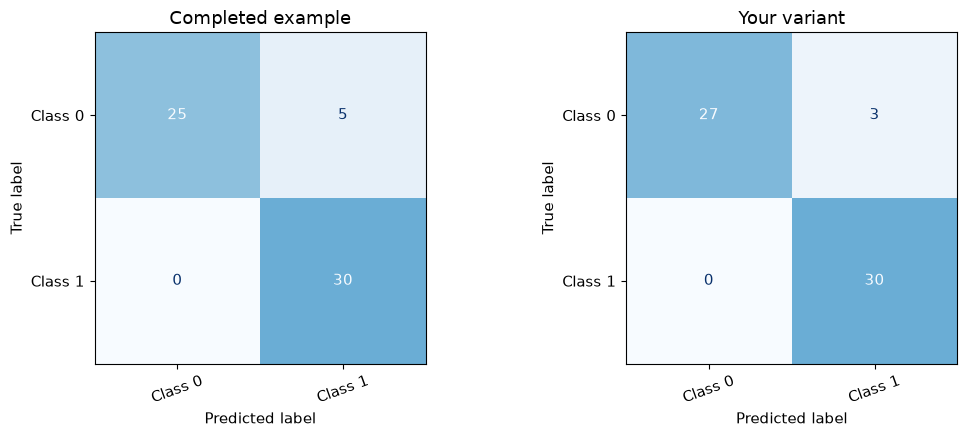

In [17]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

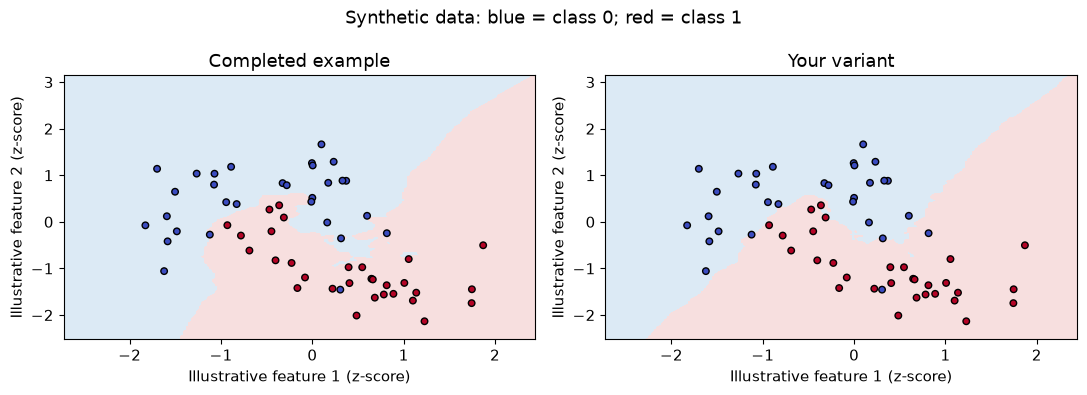

In [18]:
# PROVIDED — visualize both fitted models in the same two-feature space.
# Background colors are predictions; points show actual VALIDATION labels.
plot_train = X_train_scaled
plot_valid = X_valid_scaled
# Set plot limits from training inputs; empty regions are extrapolation.
x_axis = np.linspace(plot_train[:, 0].min() - 0.5, plot_train[:, 0].max() + 0.5, 180)
y_axis = np.linspace(plot_train[:, 1].min() - 0.5, plot_train[:, 1].max() + 0.5, 180)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)  # Create a rectangular grid.
grid_inputs = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # One point per row.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_grid = reference_model.predict(grid_inputs).reshape(grid_x.shape)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_grid = changed_model.predict(grid_inputs).reshape(grid_x.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].contourf(grid_x, grid_y, reference_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[0].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[0].set_xlabel('Illustrative feature 1 (z-score)')
axes[0].set_ylabel('Illustrative feature 2 (z-score)')
axes[0].set_title('Completed example')
axes[1].contourf(grid_x, grid_y, changed_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[1].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[1].set_xlabel('Illustrative feature 1 (z-score)')
axes[1].set_ylabel('Illustrative feature 2 (z-score)')
axes[1].set_title('Your variant')
fig.suptitle('Synthetic data: blue = class 0; red = class 1')
fig.tight_layout()
plt.show()

In [19]:
# SELF-CHECK — preserve all requested settings in one table.
record_model_0 = KNeighborsClassifier(n_neighbors=5)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_0.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_0 = record_model_0.predict(X_valid_scaled)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_0 = f1_score(y_valid, record_pred_0, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_0 = confusion_matrix(y_valid, record_pred_0, labels=[0, 1])
record_model_1 = KNeighborsClassifier(n_neighbors=1)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_1.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_1 = record_model_1.predict(X_valid_scaled)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_1 = f1_score(y_valid, record_pred_1, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_1 = confusion_matrix(y_valid, record_pred_1, labels=[0, 1])
record_model_2 = KNeighborsClassifier(n_neighbors=15)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_2.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_2 = record_model_2.predict(X_valid_scaled)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_2 = f1_score(y_valid, record_pred_2, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_2 = confusion_matrix(y_valid, record_pred_2, labels=[0, 1])
experiment_record = pd.DataFrame()
experiment_record['Setting'] = [5, 1, 15]
experiment_record['Positive-class F1'] = [record_f1_0, record_f1_1, record_f1_2]
experiment_record['FP'] = [record_matrix_0[0, 1], record_matrix_1[0, 1], record_matrix_2[0, 1]]
experiment_record['FN'] = [record_matrix_0[1, 0], record_matrix_1[1, 0], record_matrix_2[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(experiment_record.round(3))

,Setting,Positive-class F1,FP,FN
0,5,0.923,5,0
1,1,0.921,4,1
2,15,0.952,3,0


**Question:** Record k=1, 5 and 15. Which setting gives the highest validation F1 here? Describe one boundary change without claiming that this k is universally best.

**One possible interpretation:** In this fixed run, class-1 F1 is **0.923 → 0.952** (reference → variant). Read the two F1 values and error counts above. A larger k smooths local decisions but can blur class boundaries; a single validation split does not establish the best k for other datasets.

### B2 — Additional: Give closer neighbors more influence

Keep k=15 and compare uniform voting with distance voting.

In [20]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = KNeighborsClassifier(n_neighbors=15, weights='uniform')
reference_model.fit(X_train_scaled, y_train)  # Store training inputs and labels.
reference_pred = reference_model.predict(X_valid_scaled)  # Predict validation labels.

In [21]:
# YOUR TURN — edit the marked setting/expression.
voting = 'distance'
changed_model = KNeighborsClassifier(n_neighbors=15, weights=voting)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid_scaled)

In [22]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.950,0.909,1.0,0.952,3,0
1,Your variant,0.967,0.938,1.0,0.968,2,0


Predictions that changed: 1


**Question:** At fixed k=15, which FP/FN counts change with distance voting? Explain what closer neighbors contribute differently.

**One possible interpretation:** In this fixed run, class-1 F1 is **0.952 → 0.968** (reference → variant). Only neighbor weights changed. Compare FP/FN as well as F1; closer votes can change predictions, but identical scores are a valid result. Distance weighting does not remove the need for appropriate scaling.

### B3 — Recommended: An arbitrary unit change

The reference multiplies feature 1 by 100 and uses unscaled distances. Turn on training-only scaling for the same unit-changed arrays.

In [23]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
train_units = X_train.copy()
valid_units = X_valid.copy()
train_units[:, 0] = train_units[:, 0] * 100  # Only the numerical unit changes.
valid_units[:, 0] = valid_units[:, 0] * 100
reference_model = KNeighborsClassifier(n_neighbors=5)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
reference_model.fit(train_units, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(valid_units)

In [24]:
# SELF-CHECK — change True to False to repeat the unscaled case.
use_scaling = True
variant_train = train_units.copy()
variant_valid = valid_units.copy()
if use_scaling:
    unit_scaler = StandardScaler()
    # Fit learns from the supplied training data. Keep validation/test data out of fitting.
    unit_scaler.fit(train_units)
    # Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
    variant_train = unit_scaler.transform(train_units)
    # Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
    variant_valid = unit_scaler.transform(valid_units)
changed_model = KNeighborsClassifier(n_neighbors=5)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(variant_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(variant_valid)

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.767,0.864,0.633,0.731,3,11
1,Your variant,0.917,0.857,1.000,0.923,5,0


Predictions that changed: 17


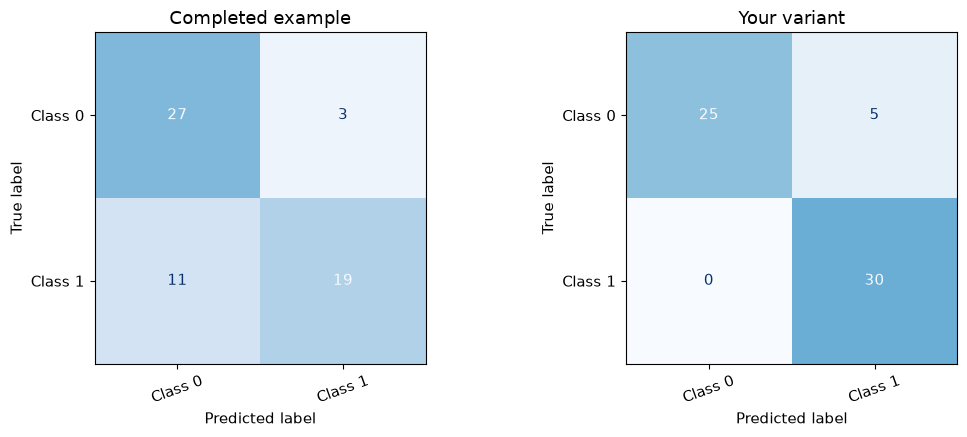

In [25]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

**Question:** Record unscaled and scaled F1. Did multiplying a coordinate by 100 add information? Explain why distances can still change.

**One possible interpretation:** In this fixed run, class-1 F1 is **0.731 → 0.923** (reference → variant). The underlying observations did not change. Unscaled distances emphasize the numerically enlarged feature; scaling restores the original standardized geometry. Scaling is not a guarantee of improved accuracy for every task.

### B4 — Additional: Training-label noise

Flip 20 training labels, then refit the same k=5 model. Keep validation labels unchanged. Is every error necessarily caused by the flips?

In [26]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = KNeighborsClassifier(n_neighbors=5, weights='uniform')
reference_model.fit(X_train_scaled, y_train)  # Store training inputs and labels.
reference_pred = reference_model.predict(X_valid_scaled)  # Predict validation labels.

In [27]:
# YOUR TURN — edit the marked setting/expression.
flip_count = 20
noisy_labels = y_train.copy()
noisy_labels[:flip_count] = 1 - noisy_labels[:flip_count]
changed_model = KNeighborsClassifier(n_neighbors=5)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train_scaled, noisy_labels)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid_scaled)

In [28]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.917,0.857,1.000,0.923,5,0
1,Your variant,0.900,0.853,0.967,0.906,5,1


Predictions that changed: 5


**Question:** Record FP/FN before and after the 20 label flips. Are all validation errors new? Explain why the original labels must be copied.

**One possible interpretation:** In this fixed run, class-1 F1 is **0.923 → 0.906** (reference → variant). Only training labels were corrupted; validation remains fixed. Compare the matrices rather than assuming noise must reduce this one score. Some validation errors already existed before the corruption.

<a id="module-c"></a>

## C — Gaussian Naive Bayes

GaussianNB models each feature with a class-specific Gaussian distribution and
assumes features are independent **conditional on class**. Low correlation in the pooled data does not establish independence within each class. A prior describes class probabilities before
observing the features; it is not the final prediction probability. Smoothing
adds a variance floor for numerical stability. It is not data normalization.

**Start here:** run C setup, then the one-feature warm-up below, then C2. C3 is an additional investigation; C1 variance smoothing is a technical extension. The module data already have within-class correlation; C3 adds an exact duplicate and further repeats evidence rather than introducing dependence for the first time.

In [29]:
# PROVIDED SETUP — imports make tools available; they do not train a model.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Make two illustrative Gaussian classes with different covariance patterns.
# These are invented unitless coordinates, not a manufacturing experiment.
rng = np.random.default_rng(19)
class_zero = rng.multivariate_normal([-1, 0], [[1, 0.7], [0.7, 1]], size=120)
class_one = rng.multivariate_normal([1, 0.6], [[1, -0.6], [-0.6, 1]], size=120)
X = np.vstack([class_zero, class_one])  # Stack the two class tables.
y = np.concatenate([np.zeros(120, dtype=int), np.ones(120, dtype=int)])
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print('Training / validation rows:', len(y_train), len(y_valid))

Training / validation rows: 180 60


### Completed warm-up — one feature, two Gaussian models

Use only the first synthetic feature. For each class, GaussianNB learns a mean
and variance: the location and spread of a bell-shaped distribution. A
**likelihood** describes how compatible an input is with that class's distribution;
it is not the probability that the class is correct. The **prior** gives the class
probability before using the input. Combining prior and likelihood and normalizing
produces the model's posterior class probabilities.

Run this example unchanged. In the plot, locate each class mean and the overlap.
In the table, compare the class probabilities at inputs −1, 0 and 1. At every
input the two probabilities sum to 1. Overlap means the input need not identify
the class with certainty. These are model estimates, not verified physical risks.
The warm-up is explanatory, not a new exercise or a model-selection experiment.
C2 returns to the original two-feature inputs and changes only the prior.

,Feature 1,P(class 0 | input),P(class 1 | input)
0,-1.0,0.899,0.101
1,0.0,0.542,0.458
2,1.0,0.151,0.849


Class order: [0 1]
Learned class priors: [0.5 0.5]


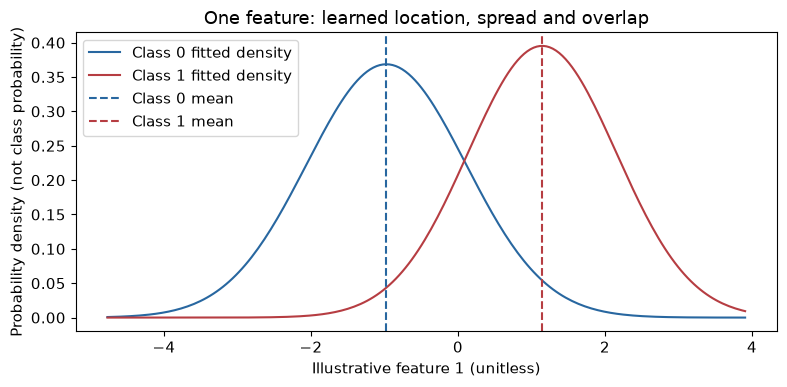

In [30]:
# PROVIDED WARM-UP — a separate model; preserve all module data and models.
# [:, [0]] keeps a two-dimensional table containing only the first feature.
intro_train = X_train[:, [0]]
intro_model = GaussianNB()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
intro_model.fit(intro_train, y_train)
intro_inputs = np.array([[-1.0], [0.0], [1.0]])  # Three illustrative new inputs.
# Return one probability per class for each input row; classes_ gives the column order.
intro_probabilities = intro_model.predict_proba(intro_inputs)
intro_table = pd.DataFrame()
intro_table['Feature 1'] = intro_inputs[:, 0]
intro_table['P(class 0 | input)'] = intro_probabilities[:, 0]
intro_table['P(class 1 | input)'] = intro_probabilities[:, 1]
# Round only the displayed table; model selection still uses the unrounded scores.
display(intro_table.round(3))
print('Class order:', intro_model.classes_)
print('Learned class priors:', intro_model.class_prior_)
# Read the learned mean and variance of feature 1 for each class.
mean_zero = intro_model.theta_[0, 0]
mean_one = intro_model.theta_[1, 0]
sd_zero = np.sqrt(intro_model.var_[0, 0])
sd_one = np.sqrt(intro_model.var_[1, 0])
intro_axis = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 200)
# Supplied Gaussian density formula; no derivation or editing is needed.
density_zero = np.exp(-0.5 * ((intro_axis - mean_zero) / sd_zero) ** 2) / (sd_zero * np.sqrt(2 * np.pi))
density_one = np.exp(-0.5 * ((intro_axis - mean_one) / sd_one) ** 2) / (sd_one * np.sqrt(2 * np.pi))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(intro_axis, density_zero, color='#2867A0', label='Class 0 fitted density')
ax.plot(intro_axis, density_one, color='#B63D42', label='Class 1 fitted density')
ax.axvline(mean_zero, color='#2867A0', linestyle='--', label='Class 0 mean')
ax.axvline(mean_one, color='#B63D42', linestyle='--', label='Class 1 mean')
ax.set_xlabel('Illustrative feature 1 (unitless)')
ax.set_ylabel('Probability density (not class probability)')
ax.set_title('One feature: learned location, spread and overlap')
ax.legend()
fig.tight_layout()
plt.show()

### C2 — Recommended: Change the prior

Use class priors [0.8, 0.2] instead of the balanced empirical prior. Do not change labels or threshold.

In [31]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = GaussianNB()  # Default empirical priors and small variance smoothing.
reference_model.fit(X_train, y_train)  # Learn class priors, means and variances.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid)

In [32]:
# YOUR TURN — edit the marked setting/expression.
class_zero_prior = 0.8
class_one_prior = 1 - class_zero_prior
changed_model = GaussianNB(priors=[class_zero_prior, class_one_prior])
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid)

In [33]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.850,0.839,0.867,0.852,5,4
1,Your variant,0.767,0.900,0.600,0.720,2,12


Predictions that changed: 11


**Question:** After increasing the class-0 prior, record class-1 precision and recall. Which error becomes more common, and why is a prior different from a measured frequency in these unchanged data?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.852 → 0.720** (reference → variant). Giving class 0 a larger prior shifts evidence toward class 0; inspect whether false positives fall and misses rise. Choosing a prior requires a justified population assumption, not simply a desire for a better validation score.

### C3 — Additional: Duplicate evidence is not new information

Enable a duplicate of the first input feature. Observe labels AND predicted probabilities. The original inputs are already dependent within each class; the duplicate adds no new information.

In [34]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = GaussianNB()  # Default empirical priors and small variance smoothing.
reference_model.fit(X_train, y_train)  # Learn class priors, means and variances.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid)
# Return one probability per class for each input row; classes_ gives the column order.
reference_probability = reference_model.predict_proba(X_valid)[:, 1]

In [35]:
# YOUR TURN — edit the marked setting/expression.
duplicate_feature = True
variant_train = X_train.copy()
variant_valid = X_valid.copy()
if duplicate_feature:
    variant_train = np.column_stack([X_train, X_train[:, 0]])
    variant_valid = np.column_stack([X_valid, X_valid[:, 0]])
changed_model = GaussianNB()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(variant_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(variant_valid)
# Return one probability per class for each input row; classes_ gives the column order.
changed_probability = changed_model.predict_proba(variant_valid)[:, 1]
print('First five original / duplicate probabilities:')
print(reference_probability[:5])
print(changed_probability[:5])

First five original / duplicate probabilities:
[0.93690908 0.95941234 0.91804291 0.16818895 0.95891469]
[0.9946769  0.99768886 0.98567824 0.02899737 0.99678248]


In [36]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.850,0.839,0.867,0.852,5,4
1,Your variant,0.833,0.833,0.833,0.833,5,5


Predictions that changed: 3


**Question:** Compare one displayed probability before/after duplication and the F1 scores. What new physical information did the duplicate provide?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.852 → 0.833** (reference → variant). An exact duplicate adds no new information, but GaussianNB treats it as another conditional likelihood factor. Probability changes can occur even if labels remain unchanged. A higher confidence value is not evidence of better calibration.

### C1 — Additional: Variance smoothing

Compare default var_smoothing=1e-9 with 0.1; then try 1.0. Keep data fixed.

In [37]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = GaussianNB()  # Default empirical priors and small variance smoothing.
reference_model.fit(X_train, y_train)  # Learn class priors, means and variances.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid)

In [38]:
# YOUR TURN — edit the marked setting/expression.
smoothing = 0.1
changed_model = GaussianNB(var_smoothing=smoothing)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid)

In [39]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.85,0.839,0.867,0.852,5,4
1,Your variant,0.85,0.839,0.867,0.852,5,4


Predictions that changed: 0


In [40]:
# SELF-CHECK — preserve all requested settings in one table.
record_model_0 = GaussianNB(var_smoothing=1e-09)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_0.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_0 = record_model_0.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_0 = f1_score(y_valid, record_pred_0, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_0 = confusion_matrix(y_valid, record_pred_0, labels=[0, 1])
record_model_1 = GaussianNB(var_smoothing=0.1)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_1.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_1 = record_model_1.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_1 = f1_score(y_valid, record_pred_1, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_1 = confusion_matrix(y_valid, record_pred_1, labels=[0, 1])
record_model_2 = GaussianNB(var_smoothing=1.0)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_2.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_2 = record_model_2.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_2 = f1_score(y_valid, record_pred_2, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_2 = confusion_matrix(y_valid, record_pred_2, labels=[0, 1])
experiment_record = pd.DataFrame()
experiment_record['Setting'] = [1e-09, 0.1, 1.0]
experiment_record['Positive-class F1'] = [record_f1_0, record_f1_1, record_f1_2]
experiment_record['FP'] = [record_matrix_0[0, 1], record_matrix_1[0, 1], record_matrix_2[0, 1]]
experiment_record['FN'] = [record_matrix_0[1, 0], record_matrix_1[1, 0], record_matrix_2[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(experiment_record.round(3))

,Setting,Positive-class F1,FP,FN
0,0.0,0.852,5,4
1,0.1,0.852,5,4
2,1.0,0.852,5,4


**Question:** Use your three recorded F1 scores to describe the effect of smoothing. If labels do not change, does that prove the estimated probabilities are identical? Explain what the displayed label-based metrics can establish.

**One possible interpretation:** In this fixed run, class-1 F1 is **0.852 → 0.852** (reference → variant). A larger variance floor changes the likelihood calculation; it may leave every predicted label unchanged. It does not repair the conditional-independence assumption or guarantee better probability estimates.

<a id="module-d"></a>

## D — Apply the models to PHM tool wear

The course feature table derives from the PHM Society 2010 Data Challenge:
945 cuts, 315 each for c1/c4/c6. Wear is the mean of three flute measurements
in micrometers. This is a course-defined classification task, not the original
competition benchmark or an industrial replacement rule. Normal combines
Slight (≤75 µm) and Intermediate (>75 and <150 µm); Severe is ≥150 µm.

Use the 11 Lab 5 sensor summaries. Wear, cutter ID and cut number are not inputs.
Forces are in N, vibrations in g, AE-RMS in V; scaled inputs are unitless.
Features summarize full recordings, not an inferred engaged-cut interval.
Use c1/c4 only with the same Lab split. Adjacent cuts can be correlated across
train/validation; these scores do not demonstrate transfer to another cutter.
Do not use c6 to choose settings. Inspecting many variants can overfit validation.

[Dataset README](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/README.md) ·
[Data dictionary](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/DATA_DICTIONARY.md).
Follow their provenance and rights notes; the course license does not relicense
source data. No raw recordings are required.

In [41]:
# PROVIDED SETUP — imports make tools available; they do not train a model.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Prefer a local CSV beside the notebook; otherwise retrieve the public course file.
data_path = Path('phm2010_features.csv')
if data_path.exists():
    data = pd.read_csv(data_path)
else:
    data = pd.read_csv('https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/data/phm2010/features/phm2010_features.csv')
# Reject outdated labels without changing the CSV.
expected = pd.Series(0, index=data.index)
expected.loc[data['wear_mean_um'] > 75] = 1
expected.loc[data['wear_mean_um'] >= 150] = 2
if not np.array_equal(expected, data['wear_level']):
    raise ValueError('Download the current course CSV with 75/150 micrometer boundaries.')
# Use c1/c4 only. Do not fit, score or plot c6 in this Practice.
development_rows = data['cutter_id'].isin(['c1', 'c4'])
development = data.loc[development_rows].copy()
class_text = development['wear_level'].astype(str)
strata = development['cutter_id'] + '_' + class_text
train, valid = train_test_split(development, test_size=0.20, random_state=42, stratify=strata)
train = train.sort_index()
valid = valid.sort_index()
sensor_features = ['force_x_mean', 'force_x_sd', 'force_y_mean', 'force_y_sd',
    'force_z_mean', 'force_z_sd', 'vibration_x_sd', 'vibration_y_sd',
    'vibration_z_sd', 'ae_rms_mean', 'ae_rms_sd']
X_train = train[sensor_features]
X_valid = valid[sensor_features]
y_train_multi = train['wear_level']
y_valid_multi = valid['wear_level']
# Binary 1 means Severe wear; multiclass 1 means Intermediate-wear.
train_severe = y_train_multi == 2
valid_severe = y_valid_multi == 2
# Convert each Boolean decision into a class label: True becomes 1, False becomes 0.
y_train = train_severe.astype(int)
# Convert each Boolean decision into a class label: True becomes 1, False becomes 0.
y_valid = valid_severe.astype(int)
scaler = StandardScaler()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
scaler.fit(X_train)
# Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
X_train_scaled = scaler.transform(X_train)
# Reuse the training scaling parameters; do not learn new scaling from validation/test rows.
X_valid_scaled = scaler.transform(X_valid)
print('Training / validation rows:', len(train), len(valid))
display(pd.crosstab(train['cutter_id'], train['wear_level']))
display(pd.crosstab(valid['cutter_id'], valid['wear_level']))

Training / validation rows: 504 126


wear_level,0,1,2
cutter_id,,,
c1,22,207,23
c4,60,155,37


wear_level,0,1,2
cutter_id,,,
c1,5,52,6
c4,15,39,9


### D1 — Additional: Binary kNN on sensor summaries

Change k=5 to k=15. Use Severe F1, and identify one matrix entry that changes or stays unchanged.

In [42]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = KNeighborsClassifier(n_neighbors=5, weights='uniform')
reference_model.fit(X_train_scaled, y_train)  # Store training inputs and labels.
reference_pred = reference_model.predict(X_valid_scaled)  # Predict validation labels.

In [43]:
# YOUR TURN — edit the marked setting/expression.
k = 15
changed_model = KNeighborsClassifier(n_neighbors=k)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train_scaled, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid_scaled)

In [44]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
names = ['Normal wear', 'Severe wear']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,1.0,1.0,1.0,1.0,0,0
1,Your variant,1.0,1.0,1.0,1.0,0,0


Predictions that changed: 0


**Question:** Record Severe F1 and changed-prediction count for k=5 and 15. If they are identical, state that explicitly. Why does this not establish performance on c6?

**One possible interpretation:** In this fixed run, Severe F1 is **1.000 → 1.000** (reference → variant). Both matrices classify all 126 validation rows correctly. This is within-cutter validation, not evidence of deployment readiness. Compare Severe F1 using the same 126 validation cuts. This comparison isolates k within kNN; it does not establish a model ranking on unseen cutters. An unchanged prediction is a legitimate observation.

### D2 — Recommended: GaussianNB with three wear classes

Compare GaussianNB with kNN (k=5) using three-class targets and the same scaled inputs. Use macro-F1, not binary F1.

In [45]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid_multi
reference_model = GaussianNB()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
reference_model.fit(X_train_scaled, y_train_multi)
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid_scaled)

In [46]:
# YOUR TURN — edit the marked setting/expression.
changed_model = KNeighborsClassifier(n_neighbors=5)
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train_scaled, y_train_multi)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid_scaled)

,Case,Macro-F1,Weighted-F1
0,Completed example,0.762,0.792
1,Your variant,1.000,1.000


              precision    recall  f1-score   support

           0      1.000     1.000     1.000        20
           1      1.000     1.000     1.000        91
           2      1.000     1.000     1.000        15

    accuracy                          1.000       126
   macro avg      1.000     1.000     1.000       126
weighted avg      1.000     1.000     1.000       126



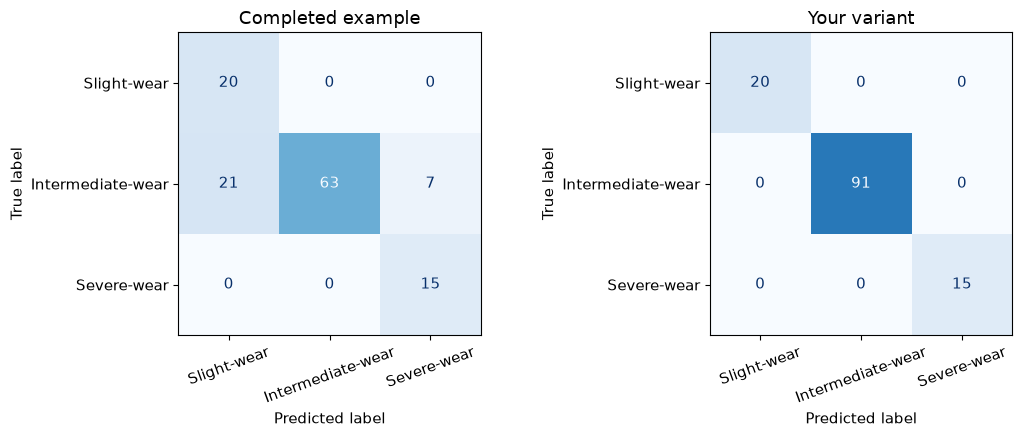

In [47]:
# PROVIDED REPORTING — optional reading; run unchanged.
# macro-F1 weights each class equally; weighted-F1 uses support.
reference_f1 = f1_score(actual, reference_pred, labels=[0, 1, 2], average='macro', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, labels=[0, 1, 2], average='macro', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_weighted = f1_score(actual, reference_pred, labels=[0, 1, 2], average='weighted', zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_weighted = f1_score(actual, changed_pred, labels=[0, 1, 2], average='weighted', zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Macro-F1'] = [reference_f1, changed_f1]
comparison['Weighted-F1'] = [reference_weighted, changed_weighted]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
labels = [0, 1, 2]
names = ['Class 0', 'Class 1', 'Class 2']
print(classification_report(actual, changed_pred, labels=labels, digits=3, zero_division=0))
names = ['Slight-wear', 'Intermediate-wear', 'Severe-wear']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

**Question:** Record both macro-F1 scores. Identify the most common GaussianNB actual-to-predicted error and its count. What does the shared c1/c4 split allow you to compare, and what does it not establish?

**One possible interpretation:** In this fixed run, macro-F1 is **0.762 → 1.000** (reference → variant). Both models see identical rows, inputs and targets. Compare macro-F1 and individual class recall/support. Conditional dependence among sensor summaries may limit GaussianNB, but this score difference alone does not prove that dependence caused the difference.

### D3 — Additional: Change a GaussianNB decision threshold

Hold one fitted binary GaussianNB fixed and change its Severe threshold from 0.50 to 0.25. Compare FP/FN.

In [48]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = GaussianNB()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
reference_model.fit(X_train_scaled, y_train)
print('Probability columns:', reference_model.classes_)  # Order is [0, 1].
# Return one probability per class for each input row; classes_ gives the column order.
probabilities = reference_model.predict_proba(X_valid_scaled)
severe_probability = probabilities[:, 1]  # All rows, second column.
# The comparison is True where the estimated positive-class probability reaches the cutoff.
reference_pred = (severe_probability >= 0.50).astype(int)

Probability columns: [0 1]


In [49]:
# YOUR TURN — edit the marked setting/expression.
threshold = 0.25
# The comparison is True where the estimated positive-class probability reaches the cutoff.
is_severe = severe_probability >= threshold
# Convert each Boolean decision into a class label: True becomes 1, False becomes 0.
changed_pred = is_severe.astype(int)

In [50]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
names = ['Normal wear', 'Severe wear']
# Lowering from 0.50 to 0.25 changes only probabilities in this half-open interval.
above_lower = severe_probability >= 0.25
below_upper = severe_probability < 0.50
in_interval = above_lower & below_upper
print('Probabilities in [0.25, 0.50):', np.count_nonzero(in_interval))
print('Actual thresholds compared: 0.50 and', threshold)

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.944,0.682,1.0,0.811,7,0
1,Your variant,0.944,0.682,1.0,0.811,7,0


Predictions that changed: 0
Probabilities in [0.25, 0.50): 0
Actual thresholds compared: 0.50 and 0.25


**Question:** How many probabilities lie in [0.25, 0.50)? Use that count to explain the changed-prediction count and FP/FN at the two thresholds.

**One possible interpretation:** In this fixed run, Severe F1 is **0.811 → 0.811** (reference → variant). Both thresholds give FP=7 and FN=0; no probability crosses the changed decision interval. Lowering the threshold cannot remove a positive prediction on these fixed probabilities, so FP cannot decrease and FN cannot increase. Either can remain unchanged. This is a validation experiment, not selection of an industrial threshold or proof of calibrated probabilities.

<a id="module-e"></a>

## E — Optional depth: LDA and QDA

Linear Discriminant Analysis (LDA) shares a within-class covariance matrix across
classes; Quadratic Discriminant Analysis (QDA) allows a separate matrix per class.
Both use Gaussian class-conditional models. QDA is more flexible but must estimate
more parameters. These classifiers do not require a prior dimensionality-reduction
step. Use the synthetic Gaussian setup; this section is optional.

In [51]:
# PROVIDED SETUP — imports make tools available; they do not train a model.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Make two illustrative Gaussian classes with different covariance patterns.
# These are invented unitless coordinates, not a manufacturing experiment.
rng = np.random.default_rng(19)
class_zero = rng.multivariate_normal([-1, 0], [[1, 0.7], [0.7, 1]], size=120)
class_one = rng.multivariate_normal([1, 0.6], [[1, -0.6], [-0.6, 1]], size=120)
X = np.vstack([class_zero, class_one])  # Stack the two class tables.
y = np.concatenate([np.zeros(120, dtype=int), np.ones(120, dtype=int)])
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print('Training / validation rows:', len(y_train), len(y_valid))

Training / validation rows: 180 60


### E1 — Additional: Shared versus class-specific covariance

Replace LDA with QDA. The generated classes have different covariances, but a finite validation sample need not reward extra flexibility.

In [52]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = LinearDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
reference_model.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid)

In [53]:
# YOUR TURN — edit the marked setting/expression.
changed_model = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid)

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.85,0.862,0.833,0.847,4,5
1,Your variant,0.85,0.862,0.833,0.847,4,5


Predictions that changed: 8


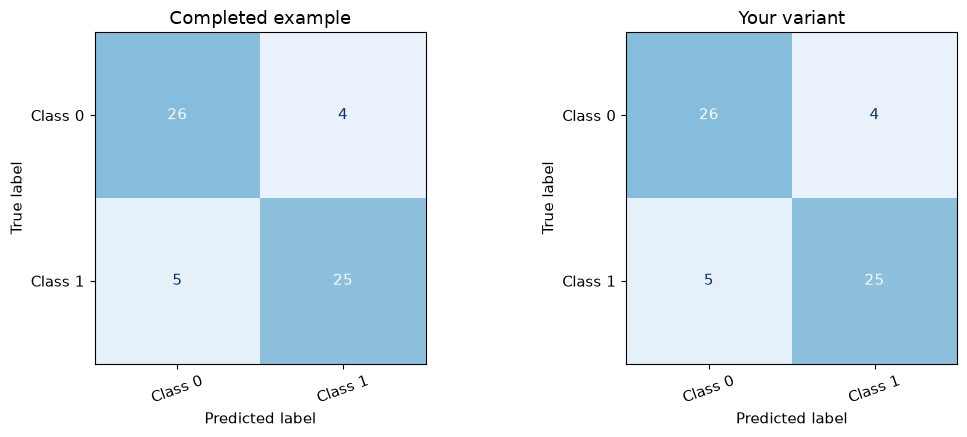

In [54]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']
# fig is the full figure; axes[0] and axes[1] are its two panels.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Rows are actual classes and columns are predictions. Keep the same color scale.
ConfusionMatrixDisplay.from_predictions(actual, reference_pred, labels=labels,
    display_labels=names, ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
ConfusionMatrixDisplay.from_predictions(actual, changed_pred, labels=labels,
    display_labels=names, ax=axes[1], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].images[0].set_clim(0, len(actual))
axes[1].images[0].set_clim(0, len(actual))
axes[0].set_title('Completed example')
axes[1].set_title('Your variant')
fig.tight_layout()  # Make room for labels.
plt.show()  # Display the figure.

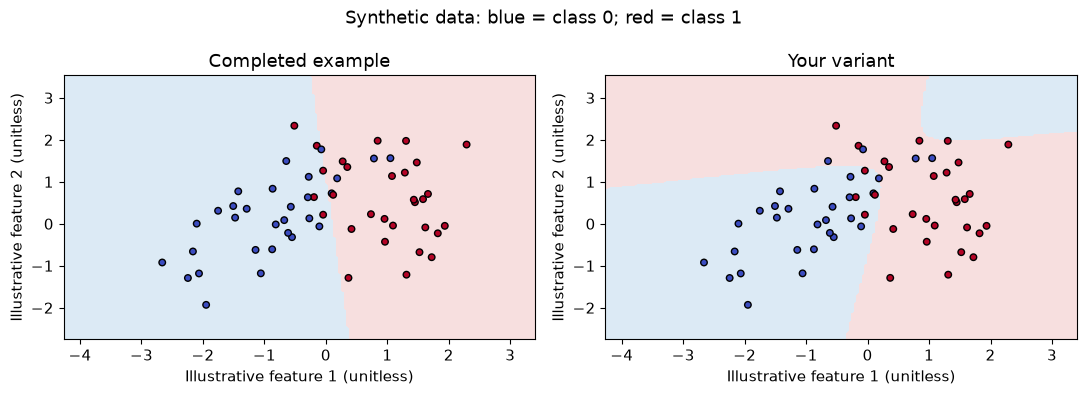

In [55]:
# PROVIDED — visualize both fitted models in the same two-feature space.
# Background colors are predictions; points show actual VALIDATION labels.
plot_train = X_train
plot_valid = X_valid
# Set plot limits from training inputs; empty regions are extrapolation.
x_axis = np.linspace(plot_train[:, 0].min() - 0.5, plot_train[:, 0].max() + 0.5, 180)
y_axis = np.linspace(plot_train[:, 1].min() - 0.5, plot_train[:, 1].max() + 0.5, 180)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)  # Create a rectangular grid.
grid_inputs = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # One point per row.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_grid = reference_model.predict(grid_inputs).reshape(grid_x.shape)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_grid = changed_model.predict(grid_inputs).reshape(grid_x.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].contourf(grid_x, grid_y, reference_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[0].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[0].set_xlabel('Illustrative feature 1 (unitless)')
axes[0].set_ylabel('Illustrative feature 2 (unitless)')
axes[0].set_title('Completed example')
axes[1].contourf(grid_x, grid_y, changed_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[1].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[1].set_xlabel('Illustrative feature 1 (unitless)')
axes[1].set_ylabel('Illustrative feature 2 (unitless)')
axes[1].set_title('Your variant')
fig.suptitle('Synthetic data: blue = class 0; red = class 1')
fig.tight_layout()
plt.show()

**Question:** Compare the shapes and F1 scores. Can different boundaries produce the same score? Are empty regions of the plot supported by observed data?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.847 → 0.847** (reference → variant). The boundary shapes differ even though the aggregate scores are identical. QDA can represent curved boundaries using separate class covariances. Compare its F1 and error pattern rather than assuming it must win; the example is synthetic and its covariance structure was deliberately chosen.

### E2 — Additional: QDA with fewer observations

Fit QDA using only the first 20 training rows; keep validation unchanged. Compare with QDA using all 180 training rows.

After recording the 20-row result, change `training_count` to 40 and rerun the action and reporting cells. Preserve both results in the table.

In [56]:
# COMPLETED EXAMPLE — run unchanged.
actual = y_valid
reference_model = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
reference_model.fit(X_train, y_train)
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_pred = reference_model.predict(X_valid)

In [57]:
# YOUR TURN — edit the marked setting/expression.
training_count = 20
small_X = X_train[:training_count]
small_y = y_train[:training_count]
print('Subset counts:', np.bincount(small_y))
changed_model = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
changed_model.fit(small_X, small_y)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_pred = changed_model.predict(X_valid)

Subset counts: [ 8 12]


In [58]:
# PROVIDED REPORTING — optional reading; run unchanged.
# compare the two predictions on the SAME validation labels.
# Class 1 is positive. zero_division=0 reports zero for an undefined metric.
reference_accuracy = accuracy_score(actual, reference_pred)
changed_accuracy = accuracy_score(actual, changed_pred)
reference_precision = precision_score(actual, reference_pred, zero_division=0)
changed_precision = precision_score(actual, changed_pred, zero_division=0)
reference_recall = recall_score(actual, reference_pred, zero_division=0)
changed_recall = recall_score(actual, changed_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
reference_f1 = f1_score(actual, reference_pred, zero_division=0)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
changed_f1 = f1_score(actual, changed_pred, zero_division=0)
comparison = pd.DataFrame()
comparison['Case'] = ['Completed example', 'Your variant']
comparison['Accuracy'] = [reference_accuracy, changed_accuracy]
comparison['Precision (class 1)'] = [reference_precision, changed_precision]
comparison['Recall (class 1)'] = [reference_recall, changed_recall]
comparison['F1 (class 1)'] = [reference_f1, changed_f1]
# Count errors explicitly so you do not need a matrix for every experiment.
reference_matrix = confusion_matrix(actual, reference_pred, labels=[0, 1])
# Count actual labels by row and predicted labels by column, in the specified label order.
changed_matrix = confusion_matrix(actual, changed_pred, labels=[0, 1])
comparison['False positives'] = [reference_matrix[0, 1], changed_matrix[0, 1]]
comparison['False negatives'] = [reference_matrix[1, 0], changed_matrix[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(comparison.round(3))
changed_prediction_count = np.count_nonzero(reference_pred != changed_pred)
print('Predictions that changed:', changed_prediction_count)
labels = [0, 1]
names = ['Class 0', 'Class 1']

,Case,Accuracy,Precision (class 1),Recall (class 1),F1 (class 1),False positives,False negatives
0,Completed example,0.85,0.862,0.833,0.847,4,5
1,Your variant,0.85,0.818,0.900,0.857,6,3


Predictions that changed: 4


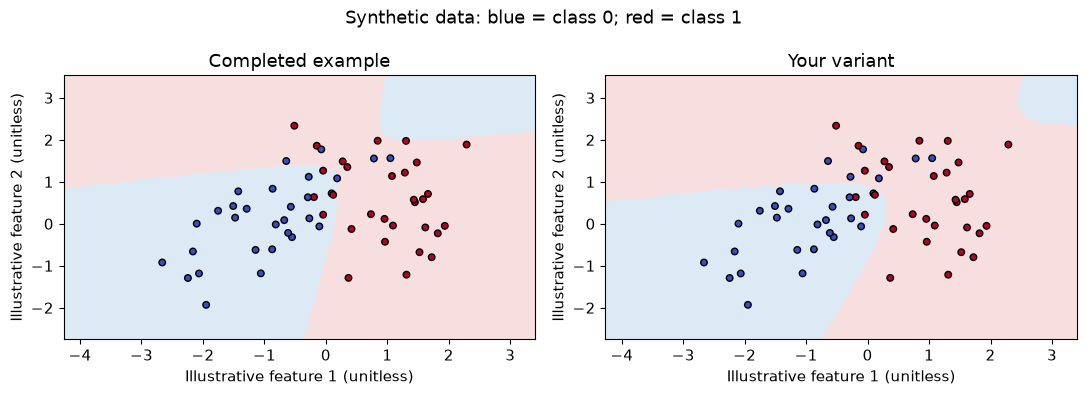

In [59]:
# PROVIDED — visualize both fitted models in the same two-feature space.
# Background colors are predictions; points show actual VALIDATION labels.
plot_train = X_train
plot_valid = X_valid
# Set plot limits from training inputs; empty regions are extrapolation.
x_axis = np.linspace(plot_train[:, 0].min() - 0.5, plot_train[:, 0].max() + 0.5, 180)
y_axis = np.linspace(plot_train[:, 1].min() - 0.5, plot_train[:, 1].max() + 0.5, 180)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)  # Create a rectangular grid.
grid_inputs = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # One point per row.
# Use the fitted model to assign labels to these rows; predict does not train the model.
reference_grid = reference_model.predict(grid_inputs).reshape(grid_x.shape)
# Use the fitted model to assign labels to these rows; predict does not train the model.
changed_grid = changed_model.predict(grid_inputs).reshape(grid_x.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].contourf(grid_x, grid_y, reference_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[0].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[0].set_xlabel('Illustrative feature 1 (unitless)')
axes[0].set_ylabel('Illustrative feature 2 (unitless)')
axes[0].set_title('Completed example')
axes[1].contourf(grid_x, grid_y, changed_grid, levels=[-0.5, 0.5, 1.5], colors=['#DCEAF5', '#F7DFDF'])
axes[1].scatter(plot_valid[:, 0], plot_valid[:, 1], c=y_valid, cmap='coolwarm', edgecolors='black', s=22)
axes[1].set_xlabel('Illustrative feature 1 (unitless)')
axes[1].set_ylabel('Illustrative feature 2 (unitless)')
axes[1].set_title('Your variant')
fig.suptitle('Synthetic data: blue = class 0; red = class 1')
fig.tight_layout()
plt.show()

In [60]:
# SELF-CHECK — preserve all requested settings in one table.
record_model_0 = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_0.fit(X_train[:180], y_train[:180])
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_0 = record_model_0.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_0 = f1_score(y_valid, record_pred_0, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_0 = confusion_matrix(y_valid, record_pred_0, labels=[0, 1])
record_model_1 = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_1.fit(X_train[:20], y_train[:20])
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_1 = record_model_1.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_1 = f1_score(y_valid, record_pred_1, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_1 = confusion_matrix(y_valid, record_pred_1, labels=[0, 1])
record_model_2 = QuadraticDiscriminantAnalysis()
# Fit learns from the supplied training data. Keep validation/test data out of fitting.
record_model_2.fit(X_train[:40], y_train[:40])
# Use the fitted model to assign labels to these rows; predict does not train the model.
record_pred_2 = record_model_2.predict(X_valid)
# Compare actual labels with predictions. Binary F1 uses class 1; macro-F1 averages class F1 values equally.
record_f1_2 = f1_score(y_valid, record_pred_2, zero_division=0)
# Count actual labels by row and predicted labels by column, in the specified label order.
record_matrix_2 = confusion_matrix(y_valid, record_pred_2, labels=[0, 1])
experiment_record = pd.DataFrame()
experiment_record['Setting'] = [180, 20, 40]
experiment_record['Positive-class F1'] = [record_f1_0, record_f1_1, record_f1_2]
experiment_record['FP'] = [record_matrix_0[0, 1], record_matrix_1[0, 1], record_matrix_2[0, 1]]
experiment_record['FN'] = [record_matrix_0[1, 0], record_matrix_1[1, 0], record_matrix_2[1, 0]]
# Round only the displayed table; model selection still uses the unrounded scores.
display(experiment_record.round(3))

,Setting,Positive-class F1,FP,FN
0,180,0.847,4,5
1,20,0.857,6,3
2,40,0.871,5,3


**Question:** Record the 20-, 40- and 180-row results. For 20 versus 180, compare precision and recall as well as F1. Why is one nested subset insufficient to infer the general effect of sample size?

**One possible interpretation:** In this fixed run, class-1 F1 is **0.847 → 0.857** (reference → variant). Here the smaller subset has slightly higher F1, despite equal accuracy; precision falls and recall rises. Covariance estimates depend on the available observations. A smaller sample may produce unstable boundaries; a favorable score on this one subset would not show that less data is generally better. No validation rows entered fitting.

## Self-check and references

Restart and run the chosen module to check independence. The solution shows one possible route; a different setting can give a different valid result.

- PHM Society: [2010 Data Challenge](https://phmsociety.org/phm_competition/2010-phm-society-conference-data-challenge/).
- [Course feature provenance](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/data/phm2010/features/README.md).
- scikit-learn: [neighbors](https://scikit-learn.org/stable/modules/neighbors.html),
  [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html),
  [LDA/QDA](https://scikit-learn.org/stable/modules/lda_qda.html),
  [evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html).

Optional: [Lab 5 follow-up](practice05_lab_followup.ipynb) and [self-check](practice05_lab_followup_solution.ipynb) cover Logistic threshold 0.25, PHM SVM boundaries and label regrouping. These are extra activities, not additions to the recommended route.